In [218]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [219]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [220]:
df = pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [221]:
print("Shape :", df.shape)

df.info()

df.describe()

df.describe(include="object")

Shape : (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [222]:
df.shape

(7043, 21)

In [223]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [224]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)


0


In [225]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [226]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [227]:
df.isna().values.any()

np.False_

In [228]:
df["TotalCharges"].dtype

dtype('O')

In [229]:
print("Blank values in each column\n")

for col in df.columns:

    blank = (df[col].astype(str).str.strip()=="").sum()

    if blank>0:
      print(f"{col:<20} {blank}")

Blank values in each column

TotalCharges         11


In [230]:
expected_columns = [
    "customerID",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

if list(df.columns) == expected_columns:
    print("✅ Column validation passed.")
else:
    print("❌ Column mismatch detected.")

✅ Column validation passed.


In [231]:
print(df["Churn"].value_counts())

assert set(df["Churn"].unique()) == {"Yes", "No"}

print("✅ Target labels are valid.")

Churn
No     5174
Yes    1869
Name: count, dtype: int64
✅ Target labels are valid.


In [232]:
print(df[["tenure", "MonthlyCharges"]].describe())

assert (df["tenure"] >= 0).all()
assert (df["MonthlyCharges"] >= 0).all()

print("✅ Numerical ranges are valid.")

            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000
✅ Numerical ranges are valid.


In [233]:
print("Unique Customer IDs :", df["customerID"].nunique())
print("Total Rows          :", len(df))

assert df["customerID"].nunique() == len(df)

print("✅ customerID is unique.")

Unique Customer IDs : 7043
Total Rows          : 7043
✅ customerID is unique.


In [234]:
validation_report = pd.DataFrame({
    "Check": [
        "Dataset Loaded",
        "Expected Shape",
        "Duplicate Rows",
        "Missing Values",
        "Blank Strings",
        "Unique Customer IDs",
        "Target Labels"
    ],
    "Status": [
        "✅",
        "✅" if df.shape == (7043, 21) else "❌",
        "✅" if df.duplicated().sum() == 0 else "❌",
        "✅" if df.isna().sum().sum() == 0 else "❌",
        "⚠️ TotalCharges: 11 Blank Strings",
        "✅" if df["customerID"].nunique() == len(df) else "❌",
        "✅" if set(df["Churn"].unique()) == {"Yes", "No"} else "❌"
    ]
})

display(validation_report)

,Check,Status
0,Dataset Loaded,✅
1,Expected Shape,✅
2,Duplicate Rows,✅
3,Missing Values,✅
4,Blank Strings,⚠️ TotalCharges: 11 Blank Strings
5,Unique Customer IDs,✅
6,Target Labels,✅


## Phase 3.3 - Data Cleaning

In [235]:
clean_df = df.copy()

In [236]:
clean_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [237]:
clean_df.drop(columns='customerID', inplace=True)

In [238]:
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [239]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [240]:
clean_df["TotalCharges"].head(2)


,TotalCharges
0,29.85
1,1889.5


In [241]:
clean_df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [242]:
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')

In [243]:
clean_df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [244]:
clean_df['TotalCharges'].isna().sum()

np.int64(11)

In [245]:
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)

In [246]:
clean_df['TotalCharges'].isna().sum()

np.int64(0)

In [247]:
clean_df.shape

(7043, 20)

In [248]:
# clean_df.isna().any()
clean_df.isna().any(axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [249]:
clean_df.duplicated().sum()

np.int64(22)

In [250]:
clean_df.isna().sum()


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [251]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [252]:
clean_df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [253]:
clean_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [254]:
print(clean_df["Churn"].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [255]:
summary = pd.DataFrame({
    "Feature": clean_df.columns,
    "Data Type": clean_df.dtypes.values,
    "Missing Values": clean_df.isnull().sum().values,
    "Unique Values": clean_df.nunique().values
})

display(summary)

,Feature,Data Type,Missing Values,Unique Values
0,gender,object,0,2
1,SeniorCitizen,int64,0,2
2,Partner,object,0,2
3,Dependents,object,0,2
4,tenure,int64,0,73
5,PhoneService,object,0,2
6,MultipleLines,object,0,3
7,InternetService,object,0,3
8,OnlineSecurity,object,0,3
9,OnlineBackup,object,0,3


In [256]:
clean_df.to_csv("/content/drive/MyDrive/Customer Churn/Dataset/cleaned_telco.csv",index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## Phase 3.4 - Feature Engineering

### Feature 1 -  servicecount

In [257]:
# @title
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [258]:
# @title
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

clean_df["ServiceCount"] = (
    clean_df[service_columns] == "Yes"
).sum(axis=1)

print("ServiceCount feature created successfully.")

clean_df[["ServiceCount"]].head()

ServiceCount feature created successfully.


,ServiceCount
0,1
1,2
2,2
3,3
4,0


In [259]:
# @title
print("Minimum Service Count :", clean_df["ServiceCount"].min())
print("Maximum Service Count :", clean_df["ServiceCount"].max())

print("\nUnique Values:")
print(sorted(clean_df["ServiceCount"].unique()))

Minimum Service Count : 0
Maximum Service Count : 6

Unique Values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


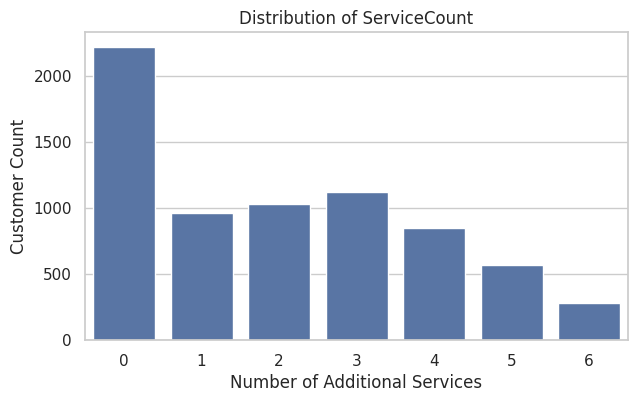

In [260]:
# @title
plt.figure(figsize=(7,4))

sns.countplot(
    data=clean_df,
    x="ServiceCount"
)

plt.title("Distribution of ServiceCount")
plt.xlabel("Number of Additional Services")
plt.ylabel("Customer Count")

plt.show()

In [261]:
# @title
service_churn = (
    pd.crosstab(
        clean_df["ServiceCount"],
        clean_df["Churn"],
        normalize="index"
    ) * 100
)

display(service_churn)

Churn,No,Yes
ServiceCount,,
0,78.593961,21.406039
1,54.244306,45.755694
2,64.181994,35.818006
3,72.629696,27.370304
4,77.699531,22.300469
5,87.565674,12.434326
6,94.718310,5.281690


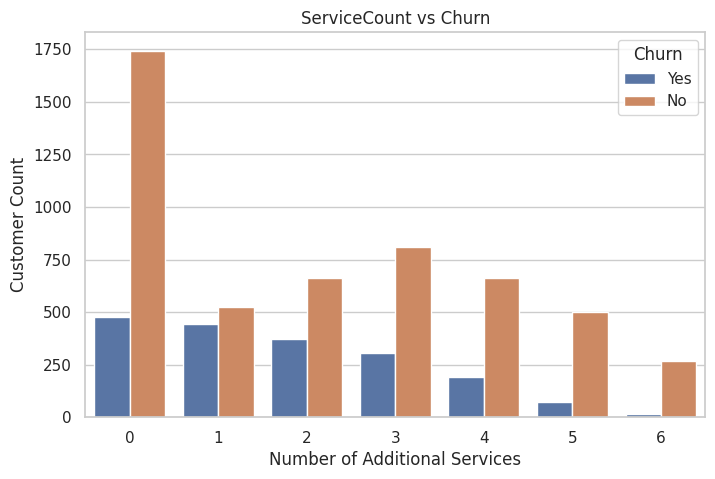

In [262]:
# @title
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="ServiceCount",
    hue="Churn"
)

plt.title("ServiceCount vs Churn")
plt.xlabel("Number of Additional Services")
plt.ylabel("Customer Count")

plt.show()

In [263]:
# @title
print("Missing Values :", clean_df["ServiceCount"].isnull().sum())
print("Data Type      :", clean_df["ServiceCount"].dtype)

Missing Values : 0
Data Type      : int64


In [264]:
# @title
pd.crosstab(
    clean_df["InternetService"],
    clean_df["ServiceCount"],
    margins=True
)

ServiceCount,0,1,2,3,4,5,6,All
InternetService,,,,,,,,
DSL,294,415,454,475,359,281,143,2421
Fiber optic,399,551,579,643,493,290,141,3096
No,1526,0,0,0,0,0,0,1526
All,2219,966,1033,1118,852,571,284,7043


In [265]:
# @title
clean_df.groupby("Churn")["ServiceCount"].mean()

,ServiceCount
Churn,
No,2.135292
Yes,1.768325


In [266]:
clean_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2


### Feature 2 - isnewcustomer

In [267]:
# @title
print("Tenure Summary Statistics\n")

display(clean_df["tenure"].describe())

Tenure Summary Statistics



,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


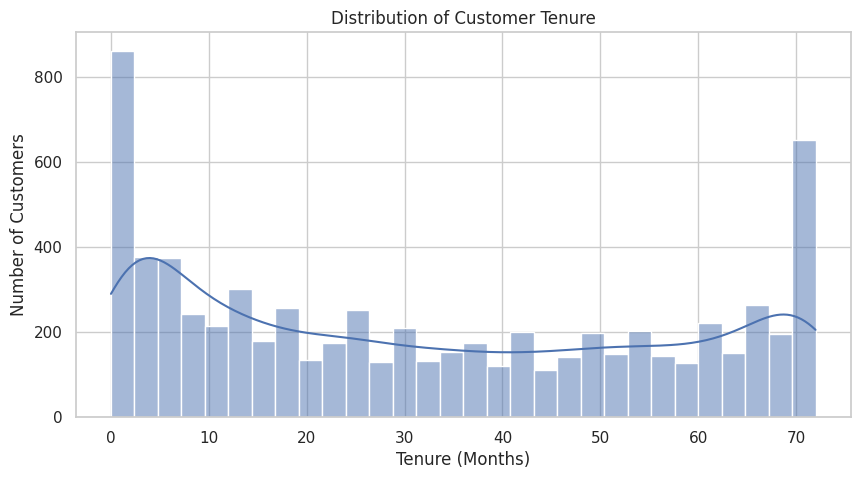

In [268]:
# @title
plt.figure(figsize=(10,5))

sns.histplot(
    data=clean_df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [269]:
# @title
tenure_analysis = (
    clean_df
    .groupby("tenure")
    .agg(
        Total_Customers=("Churn", "count"),
        Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
    )
)

tenure_analysis["Churn_Rate"] = (
    tenure_analysis["Churned_Customers"]
    / tenure_analysis["Total_Customers"]
    * 100
).round(2)

display(tenure_analysis)

,Total_Customers,Churned_Customers,Churn_Rate
tenure,,,
0,11,0,0.00
1,613,380,61.99
2,238,123,51.68
3,200,94,47.00
4,176,83,47.16
5,133,64,48.12
6,110,40,36.36
7,131,51,38.93
8,123,42,34.15


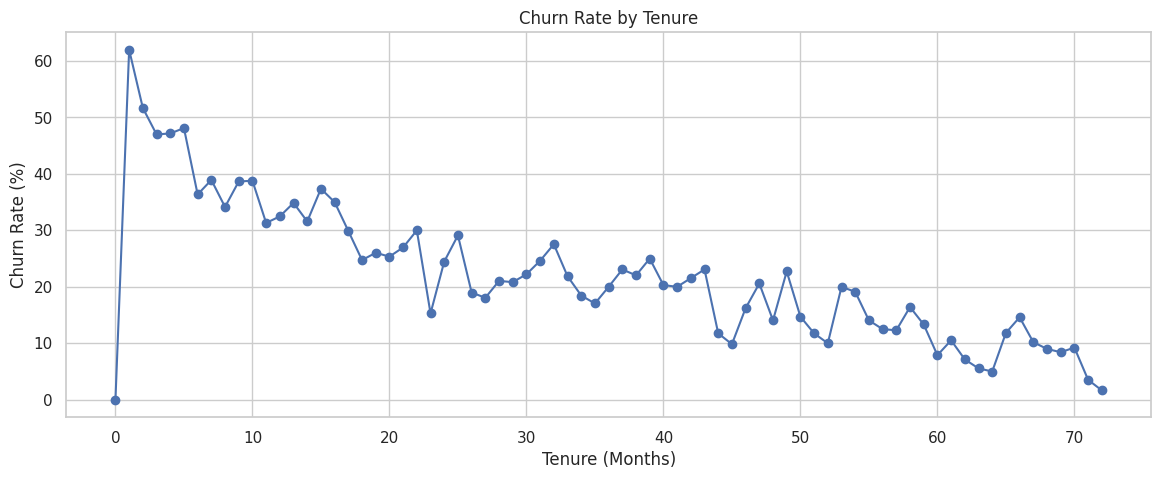

In [270]:
# @title
plt.figure(figsize=(14,5))

plt.plot(
    tenure_analysis.index,
    tenure_analysis["Churn_Rate"],
    marker="o"
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.grid(True)

plt.show()

In [271]:
# @title
tenure_bins = [0, 6, 12, 24, 48, 72]

tenure_labels = [
    "0-6 Months",
    "7-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-72 Months"
]

clean_df["TenureGroup"] = pd.cut(
    clean_df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [272]:
# @title
tenure_bucket_analysis = (
    pd.crosstab(
        clean_df["TenureGroup"],
        clean_df["Churn"],
        normalize="index"
    ) * 100
)

display(tenure_bucket_analysis)

Churn,No,Yes
TenureGroup,,
0-6 Months,47.062795,52.937205
7-12 Months,64.113475,35.886525
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


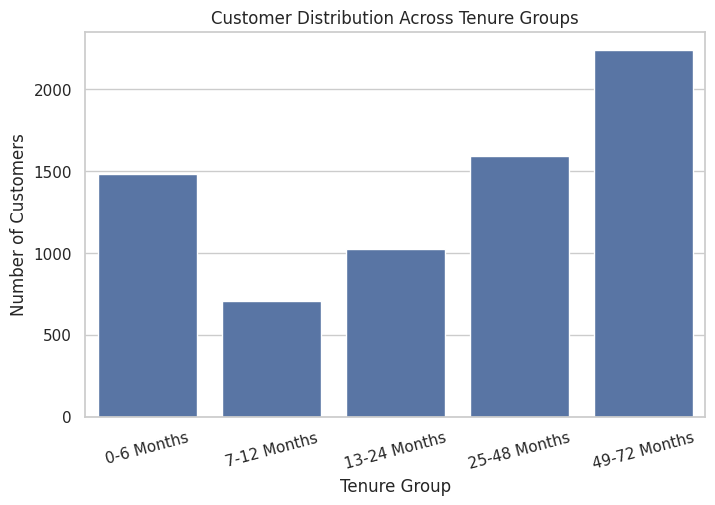

In [273]:
# @title
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="TenureGroup",
    order=tenure_labels
)

plt.title("Customer Distribution Across Tenure Groups")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

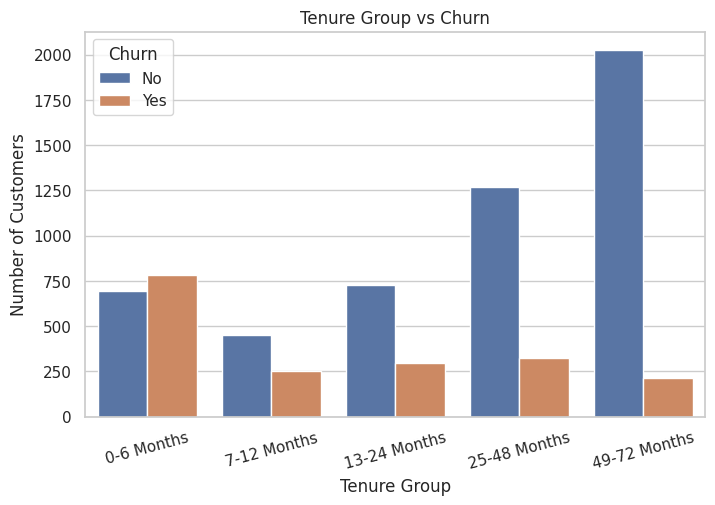

In [274]:
# @title
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="TenureGroup",
    hue="Churn",
    order=tenure_labels
)

plt.title("Tenure Group vs Churn")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [275]:
# @title
display(
    clean_df.groupby("Churn")["tenure"].mean().round(2)
)

,tenure
Churn,
No,37.57
Yes,17.98


In [276]:
clean_df["IsNewCustomer"] = np.where(
    clean_df["tenure"] <= 6,
    1,
    0
)

print("IsNewCustomer feature created successfully.")

clean_df[["tenure", "IsNewCustomer"]].head()

IsNewCustomer feature created successfully.


,tenure,IsNewCustomer
0,1,1
1,34,0
2,2,1
3,45,0
4,2,1


In [277]:
print("Value Counts\n")

print(clean_df["IsNewCustomer"].value_counts())

print("\nMissing Values :", clean_df["IsNewCustomer"].isnull().sum())

print("\nData Type :", clean_df["IsNewCustomer"].dtype)

Value Counts

IsNewCustomer
0    5562
1    1481
Name: count, dtype: int64

Missing Values : 0

Data Type : int64


In [278]:
new_customer_analysis = (
    pd.crosstab(
        clean_df["IsNewCustomer"],
        clean_df["Churn"],
        normalize="index"
    ) * 100
)

display(new_customer_analysis)

Churn,No,Yes
IsNewCustomer,,
0,80.492629,19.507371
1,47.062795,52.937205


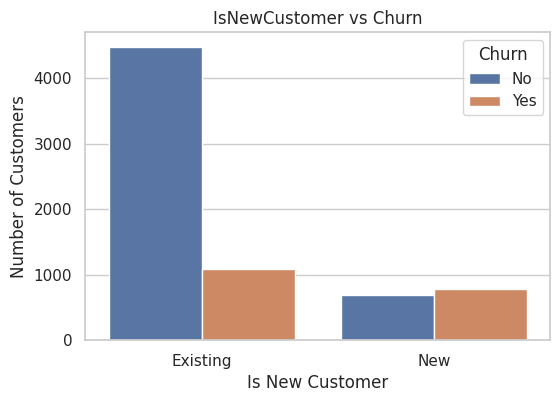

In [279]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x="IsNewCustomer",
    hue="Churn"
)

plt.title("IsNewCustomer vs Churn")
plt.xlabel("Is New Customer")
plt.ylabel("Number of Customers")

plt.xticks([0, 1], ["Existing", "New"])

plt.show()

### Feature 3 - Customer life time values

In [280]:
clean_df["CLV"] =  clean_df['tenure'] * clean_df['MonthlyCharges']

In [281]:
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,TenureGroup,IsNewCustomer,CLV
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0-6 Months,1,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2,25-48 Months,0,1936.30
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,0-6 Months,1,107.70
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,25-48 Months,0,1903.50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,0-6 Months,1,141.40


In [282]:
print("Data Type :", clean_df["CLV"].dtype)
print("Missing Values :", clean_df["CLV"].isnull().sum())
print("Negative Values :", (clean_df["CLV"] < 0).sum())

Data Type : float64
Missing Values : 0
Negative Values : 0


In [283]:
display(clean_df["CLV"].describe())

print("\nSkewness :", clean_df["CLV"].skew())

,CLV
count,7043.000000
mean,2279.581350
std,2264.729447
min,0.000000
25%,394.000000
50%,1393.600000
75%,3786.100000
max,8550.000000



Skewness : 0.9606366798869088


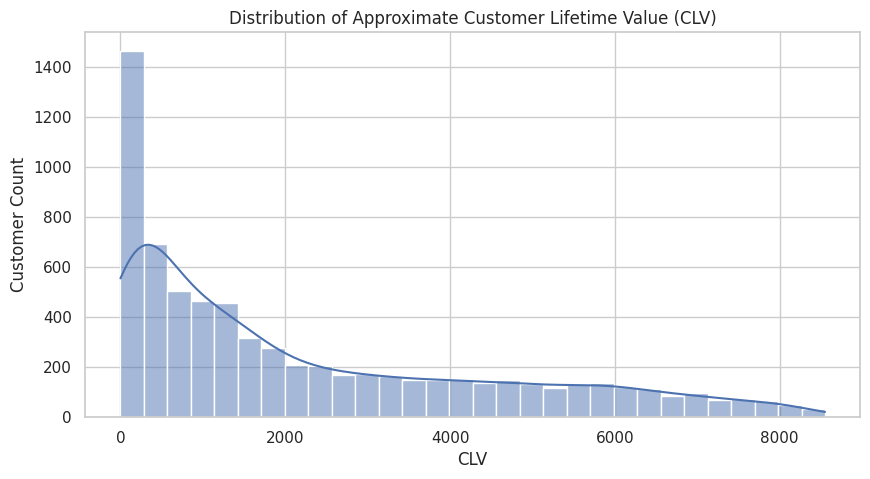

In [284]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=clean_df,
    x="CLV",
    bins=30,
    kde=True
)

plt.title("Distribution of Approximate Customer Lifetime Value (CLV)")
plt.xlabel("CLV")
plt.ylabel("Customer Count")

plt.show()

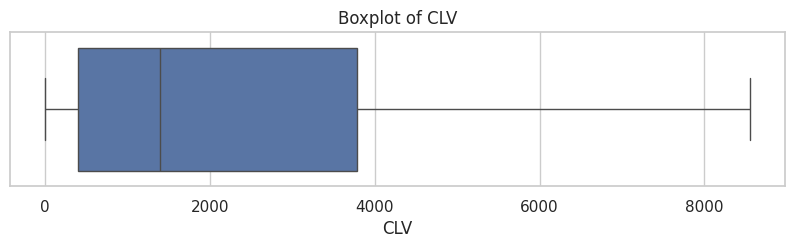

In [285]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=clean_df["CLV"]
)

plt.title("Boxplot of CLV")

plt.show()

In [286]:
display(
    clean_df.groupby("Churn")["CLV"].agg(
        ["mean", "median", "min", "max"]
    ).round(2)
)

,mean,median,min,max
Churn,,,,
No,2549.77,1687.12,0.00,8550.0
Yes,1531.61,700.00,18.85,8481.6


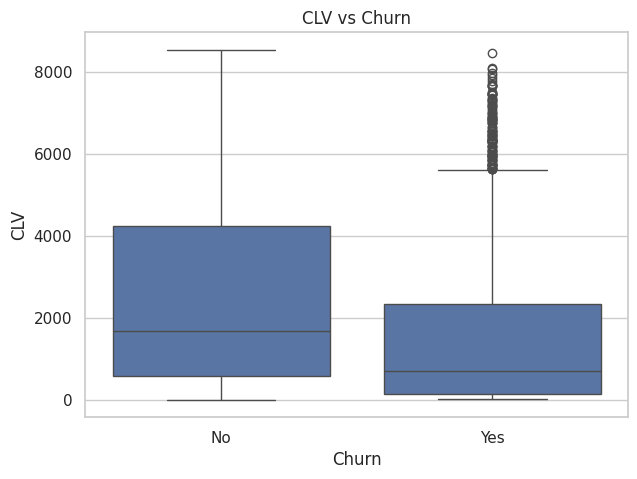

In [287]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=clean_df,
    x="Churn",
    y="CLV"
)

plt.title("CLV vs Churn")

plt.show()

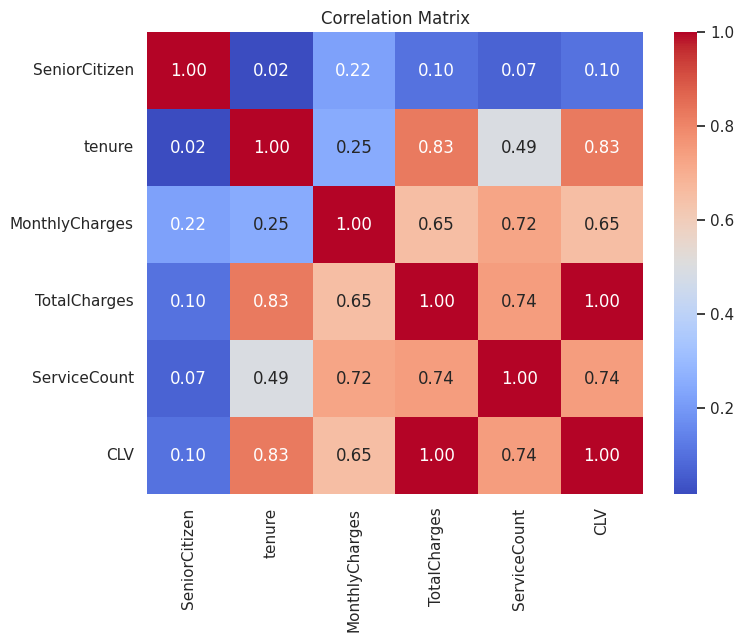

In [288]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "CLV"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    clean_df[numeric_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [289]:
display(
    clean_df.groupby("IsNewCustomer")["CLV"].mean().round(2)
)

,CLV
IsNewCustomer,
0,2848.57
1,142.70


In [290]:
clean_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,TenureGroup,IsNewCustomer,CLV
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0-6 Months,1,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2,25-48 Months,0,1936.30


In [291]:
clean_df.drop(columns="CLV",inplace=True)

In [292]:
clean_df.drop(columns="TenureGroup",inplace=True)

In [293]:
clean_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2,0


In [294]:
clean_df.shape

(7043, 22)

## Phase 3.4 - Feature selection

In [295]:
X = clean_df.drop(columns=["Churn"])
y = clean_df["Churn"]

print(f"Feature Shape : {X.shape}")
print(f"Target Shape  : {y.shape}")

Feature Shape : (7043, 21)
Target Shape  : (7043,)


In [296]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features :", len(numerical_features))
print(numerical_features)

print("\nCategorical Features :", len(categorical_features))
print(categorical_features)

Numerical Features : 6
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'IsNewCustomer']

Categorical Features : 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [297]:
# One-Hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Encoded Shape :", X_encoded.shape)

X_encoded.head()

Encoded Shape : (7043, 32)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,IsNewCustomer,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,2,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,2,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,3,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [298]:
# Encode Target

y_encoded = y.map({
    "No": 0,
    "Yes": 1
})

print(y_encoded.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [299]:
print("=" * 60)

print("Encoded Feature Shape :", X_encoded.shape)
print("Target Shape          :", y_encoded.shape)

print("\nMissing Values :", X_encoded.isnull().sum().sum())

print("Duplicate Rows :", X_encoded.duplicated().sum())

print("=" * 60)

Encoded Feature Shape : (7043, 32)
Target Shape          : (7043,)

Missing Values : 0
Duplicate Rows : 40


In [300]:
feature_names = X_encoded.columns.tolist()

print(f"Total Features After Encoding : {len(feature_names)}")

Total Features After Encoding : 32


In [301]:
from sklearn.feature_selection import VarianceThreshold

# Remove constant features only
selector = VarianceThreshold(threshold=0)

X_variance = selector.fit_transform(X_encoded)

selected_columns = X_encoded.columns[selector.get_support()]

print(f"Original Features : {X_encoded.shape[1]}")
print(f"Remaining Features : {len(selected_columns)}")
print(f"Removed Features : {X_encoded.shape[1] - len(selected_columns)}")

Original Features : 32
Remaining Features : 32
Removed Features : 0


In [302]:
removed_features = X_encoded.columns[~selector.get_support()]

print("Removed Features:\n")

if len(removed_features) == 0:
    print("No constant features found.")
else:
    for feature in removed_features:
        print(feature)

Removed Features:

No constant features found.


In [303]:
X_selected = X_encoded[selected_columns]

print("Updated Shape :", X_selected.shape)

Updated Shape : (7043, 32)


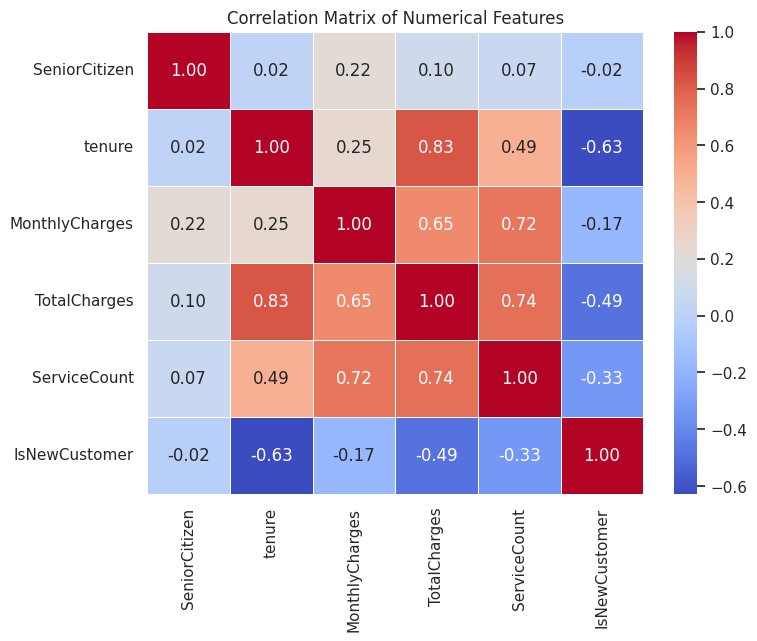

In [304]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "IsNewCustomer"
]

corr_matrix = clean_df[numeric_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [305]:
threshold = 0.90

high_corr_pairs = []

corr = corr_matrix.abs()

for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > threshold:
            high_corr_pairs.append({
                "Feature 1": corr.columns[i],
                "Feature 2": corr.columns[j],
                "Correlation": round(corr.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if high_corr_df.empty:
    print("✅ No highly correlated numerical features found.")
else:
    display(high_corr_df)

✅ No highly correlated numerical features found.


In [306]:
print("="*60)
print("Correlation Summary")
print("="*60)

for col in corr_matrix.columns:
    print(f"\n{col}")

    correlations = corr_matrix[col].drop(col).sort_values(
        key=lambda x: abs(x),
        ascending=False
    )

    print(correlations.round(3))

Correlation Summary

SeniorCitizen
MonthlyCharges    0.220
TotalCharges      0.103
ServiceCount      0.067
IsNewCustomer    -0.022
tenure            0.017
Name: SeniorCitizen, dtype: float64

tenure
TotalCharges      0.826
IsNewCustomer    -0.627
ServiceCount      0.494
MonthlyCharges    0.248
SeniorCitizen     0.017
Name: tenure, dtype: float64

MonthlyCharges
ServiceCount     0.725
TotalCharges     0.651
tenure           0.248
SeniorCitizen    0.220
IsNewCustomer   -0.172
Name: MonthlyCharges, dtype: float64

TotalCharges
tenure            0.826
ServiceCount      0.745
MonthlyCharges    0.651
IsNewCustomer    -0.487
SeniorCitizen     0.103
Name: TotalCharges, dtype: float64

ServiceCount
TotalCharges      0.745
MonthlyCharges    0.725
tenure            0.494
IsNewCustomer    -0.329
SeniorCitizen     0.067
Name: ServiceCount, dtype: float64

IsNewCustomer
tenure           -0.627
TotalCharges     -0.487
ServiceCount     -0.329
MonthlyCharges   -0.172
SeniorCitizen    -0.022
Name: IsNew

In [307]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [308]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (5634, 32)
Testing Shape  : (1409, 32)


In [309]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Random Forest trained successfully.")

✅ Random Forest trained successfully.


In [310]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,TotalCharges,0.163027
1,tenure,0.146037
2,MonthlyCharges,0.141405
3,Contract_Two year,0.048606
4,InternetService_Fiber optic,0.046135
5,ServiceCount,0.038846
6,PaymentMethod_Electronic check,0.038317
7,IsNewCustomer,0.029529
8,Contract_One year,0.026465
9,gender_Male,0.025645


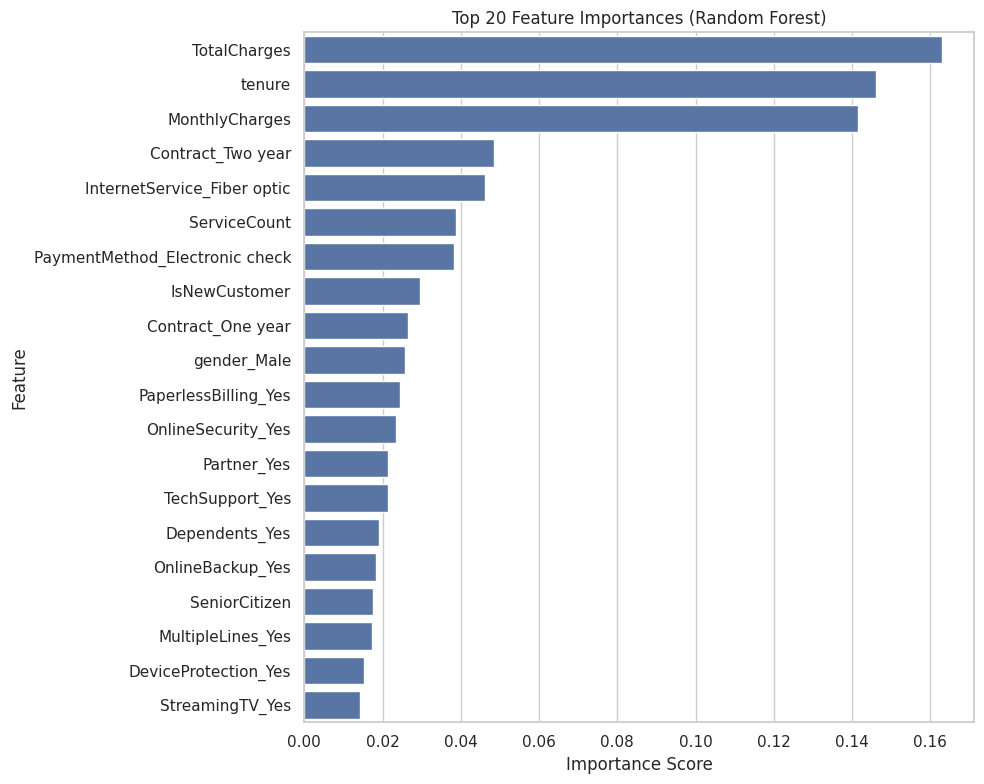

In [311]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [312]:
print("Top 10 Most Important Features\n")

display(feature_importance.head(10))

print("\nLeast Important Features\n")

display(feature_importance.tail(10))

Top 10 Most Important Features



,Feature,Importance
0,TotalCharges,0.163027
1,tenure,0.146037
2,MonthlyCharges,0.141405
3,Contract_Two year,0.048606
4,InternetService_Fiber optic,0.046135
5,ServiceCount,0.038846
6,PaymentMethod_Electronic check,0.038317
7,IsNewCustomer,0.029529
8,Contract_One year,0.026465
9,gender_Male,0.025645



Least Important Features



,Feature,Importance
22,PaymentMethod_Mailed check,0.012422
23,InternetService_No,0.009433
24,StreamingTV_No internet service,0.009373
25,OnlineSecurity_No internet service,0.008170
26,OnlineBackup_No internet service,0.008089
27,StreamingMovies_No internet service,0.007581
28,DeviceProtection_No internet service,0.006899
29,TechSupport_No internet service,0.005569
30,MultipleLines_No phone service,0.004320
31,PhoneService_Yes,0.004034


In [313]:
import os

os.makedirs("/content/drive/MyDrive/Customer Churn/Dataset/processed", exist_ok=True)

clean_df.to_csv(
    "/content/drive/MyDrive/Customer Churn/Dataset/processed/telco_clean.csv",
    index=False
)

print("✅ Clean dataset saved successfully.")

✅ Clean dataset saved successfully.


In [314]:
X_final = X_encoded.copy()
X_final["Churn"] = y_encoded

X_final.to_csv(
    "/content/drive/MyDrive/Customer Churn/Dataset/processed/telco_encoded.csv",
    index=False
)

print("✅ Encoded dataset saved successfully.")

✅ Encoded dataset saved successfully.


In [315]:
print("="*60)

print("Clean Dataset Shape")
print(clean_df.shape)

print("\nEncoded Dataset Shape")
print(X_final.shape)

print("\nColumns in Clean Dataset")
print(clean_df.columns.tolist())

print("="*60)

Clean Dataset Shape
(7043, 22)

Encoded Dataset Shape
(7043, 33)

Columns in Clean Dataset
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ServiceCount', 'IsNewCustomer']
